# Notebook 07: Fermion Doubling and the Wilson Term

**Learning objectives:**
- Understand why naive lattice fermions produce 16 species instead of 1
- Visualize the free-field dispersion relation in momentum space
- See how the Wilson term lifts doublers
- Understand the cost: explicit chiral symmetry breaking

**Prerequisites:** Notebook 06 (Wilson-Dirac operator)



In [1]:
from notebook_utils import setup_paths
setup_paths()

import numpy as np
import matplotlib.pyplot as plt
from MesonBase import build_wilson_dirac_matrix, generate_identity_gauge_field

/home/zeke/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## 1. The Doubling Problem

In the continuum, the Dirac equation for a free fermion has a single
dispersion relation: $E^2 = \vec{p}^2 + m^2$ (High Energy Physics Essentials Eq. 10.97 in Euclidean form).

On the lattice, replacing $\partial_\mu = \partial/\partial x_\mu \to \frac{1}{2a}(\delta_{x+a\hat\mu} - \delta_{x-a\hat\mu})$
leads to $\sin(p_\mu a)/a$ instead of $p_\mu$ (High Energy Physics Essentials Eq. 10.98). The sine function has
zeros not only at $p_\mu = 0$ (the physical mode) but also at
$p_\mu = \pi/a$ (the boundary of the Brillouin zone).

It's called **doubling** because it occurs independently in **each
dimension** — each dimension contributes a factor of 2. In 4D, each of
the 4 momentum components can independently be $0$ or $\pi/a$,
giving $2^4 = 16$ massless modes — the **doublers** (High Energy Physics Essentials §10.3.3; see also Smit, *Intro to QFT on Lattice* §6.2 for a textbook treatment).

## 2. Free-Field Dispersion Relation

For the naive lattice Dirac operator (Wilson $r=0$), the energy-momentum
relation in 1D is:

$$E_{\rm naive}(p) = \arcsin\bigl[\sin(pa)\bigr]/a$$

With the Wilson term ($r > 0$), the dispersion becomes:

$$E_W(p) \approx \sqrt{\sin^2(pa)/a^2 + \bigl[\frac{r}{a}(1 - \cos pa)\bigr]^2 + m^2}$$

The Wilson term adds a mass $\sim 2r/a$ at $p = \pi/a$, lifting the doubler. (High Energy Physics Essentials Eq. 10.108 gives the explicit shift $m \to m + (r/a)\sum_\mu (1 - \cos a p_\mu)$.)

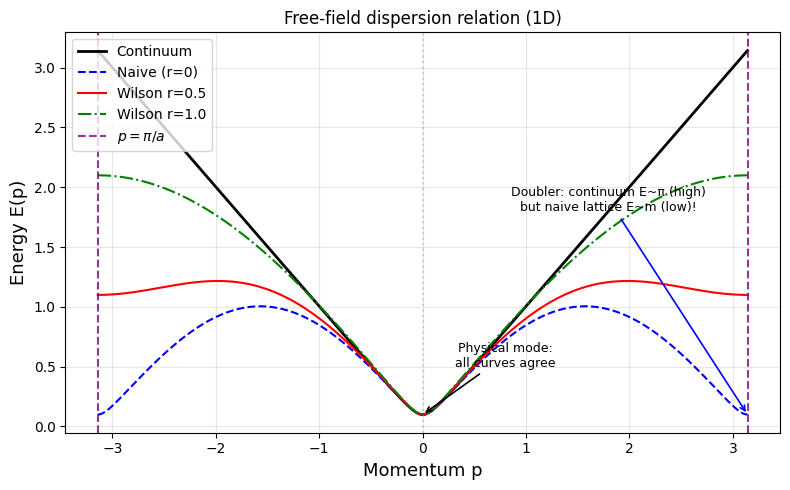

At p=0:   all curves agree (physical mode)
At p=π/a: continuum E≈3.14 (high!), naive E≈0.10 (low — doubler!)
          Wilson r=1 lifts it to E≈2.10


In [2]:
# 1D dispersion relation: naive vs Wilson
a = 1.0  # lattice spacing
p = np.linspace(-np.pi/a, np.pi/a, 500)
m = 0.1

# Naive (r=0): E^2 = sin^2(p) + m^2
E_naive = np.sqrt(np.sin(p*a)**2 / a**2 + m**2)

# Wilson r=0.5
r = 0.5
wilson_mass = (r/a) * (1 - np.cos(p*a))
E_wilson_05 = np.sqrt(np.sin(p*a)**2 / a**2 + (m + wilson_mass)**2)

# Wilson r=1.0
r = 1.0
wilson_mass = (r/a) * (1 - np.cos(p*a))
E_wilson_10 = np.sqrt(np.sin(p*a)**2 / a**2 + (m + wilson_mass)**2)

# Continuum
E_cont = np.sqrt(p**2 + m**2)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(p, E_cont, 'k-', linewidth=2, label='Continuum')
ax.plot(p, E_naive, 'b--', linewidth=1.5, label='Naive (r=0)')
ax.plot(p, E_wilson_05, 'r-', linewidth=1.5, label='Wilson r=0.5')
ax.plot(p, E_wilson_10, 'g-.', linewidth=1.5, label='Wilson r=1.0')

ax.axvline(0, color='gray', ls=':', alpha=0.3)
ax.axvline(np.pi, color='purple', ls='--', linewidth=1.5, alpha=0.8,
           label=r'$p = \pi/a$')
ax.axvline(-np.pi, color='purple', ls='--', linewidth=1.5, alpha=0.8)

# Annotate the doubler problem
ax.annotate('Physical mode:\nall curves agree',
            xy=(0, m), xytext=(0.8, 0.5),
            fontsize=9, ha='center',
            arrowprops=dict(arrowstyle='->', color='black', lw=1.2))
ax.annotate('Doubler: continuum E~π (high)\nbut naive lattice E~m (low)!',
            xy=(np.pi, E_naive[-1]), xytext=(1.8, 1.8),
            fontsize=9, ha='center',
            arrowprops=dict(arrowstyle='->', color='blue', lw=1.2))

ax.set_xlabel('Momentum p', fontsize=13)
ax.set_ylabel('Energy E(p)', fontsize=13)
ax.set_title('Free-field dispersion relation (1D)')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("At p=0:   all curves agree (physical mode)")
print(f"At p=π/a: continuum E≈{E_cont[-1]:.2f} (high!), naive E≈{E_naive[-1]:.2f} (low — doubler!)")
print(f"          Wilson r=1 lifts it to E≈{E_wilson_10[-1]:.2f}")

## 3. The Brillouin Zone and Doubler Locations

In 4D, the doublers sit at the 15 non-trivial corners of the Brillouin zone
$\mathcal{B} = [-\pi/a, \pi/a]^4$. The Wilson term gives them effective
masses proportional to the number of momentum components at $\pi/a$:

| Corner type | Count | Effective mass at $r=1$ |
|-------------|-------|------------------------|
| $(0,0,0,0)$ | 1 | $m$ (light mode) |
| $(\pi,0,0,0)$ etc. | $\binom{4}{1} = 4$ | $m + 2r/a$ |
| $(\pi,\pi,0,0)$ etc. | $\binom{4}{2} = 6$ | $m + 4r/a$ |
| $(\pi,\pi,\pi,0)$ etc. | $\binom{4}{3} = 4$ | $m + 6r/a$ |
| $(\pi,\pi,\pi,\pi)$ | 1 | $m + 8r/a$ |

Total: $1 + 4 + 6 + 4 + 1 = 16$ species, but only 1 remains light.

The corner-by-corner counting is given explicitly in High Energy Physics Essentials §10.3.3
(table on book p. 374), and Exercise 10.22 works out the doubler masses
$m + 2nr/a$ for $n = 0, 1, 2, 3, 4$.

In [3]:
# Verify: count doublers by type
from itertools import product

doubler_types = {}
for corner in product([0, 1], repeat=4):
    n_pi = sum(corner)
    if n_pi not in doubler_types:
        doubler_types[n_pi] = 0
    doubler_types[n_pi] += 1

print("Doubler classification in 4D:")
print(f"{'# components at pi/a':>22s} | {'Count':>5s} | {'Wilson mass shift':>16s}")
print("-" * 50)
for n_pi in sorted(doubler_types):
    count = doubler_types[n_pi]
    shift = 2 * n_pi  # for r=1
    label = "light mode" if n_pi == 0 else f"2r x {n_pi} = {shift}"
    print(f"{n_pi:>22d} | {count:>5d} | {label:>16s}")
print(f"{'Total':>22s} | {sum(doubler_types.values()):>5d} |")

Doubler classification in 4D:
  # components at pi/a | Count | Wilson mass shift
--------------------------------------------------
                     0 |     1 |       light mode
                     1 |     4 |       2r x 1 = 2
                     2 |     6 |       2r x 2 = 4
                     3 |     4 |       2r x 3 = 6
                     4 |     1 |       2r x 4 = 8
                 Total |    16 |


## 4. The Cost: Chiral Symmetry Breaking

The Wilson term explicitly breaks chiral symmetry. Consequences:

1. **Additive mass renormalization**: Even at $m_{\rm bare} = 0$, the quark
   acquires an effective mass $m_{\rm crit}(\beta) \neq 0$.
   The quark mass is $m_q = m_{\rm bare} - m_{\rm crit}$.

2. **No exact chiral limit**: $m_q = 0$ requires fine-tuning $m_{\rm bare}$
   to the critical value, which depends on $\beta$ and must be determined
   non-perturbatively (see Notebook 10).

3. **$O(a)$ discretization errors**: Wilson fermions have $O(a)$ artifacts
   (vs $O(a^2)$ for chirally symmetric formulations).

*Reference: High Energy Physics Essentials §10.3.3.1; see also Creutz Ch. 8 for the original discussion of chiral-symmetry breaking by the Wilson term.*

## 5. Alternative Fermion Formulations

The doubling problem has motivated several alternative approaches. The
**Nielsen–Ninomiya theorem** (cited as Ref. [9] in High Energy Physics Essentials §10.3.3)
shows that one cannot have a local, Lorentz-invariant, Hermitian lattice
fermion action without doublers unless chiral symmetry is broken — so
every formulation below sacrifices something:

| Formulation | Doublers | Chiral symmetry | Cost |
|------------|---------|-----------------|------|
| **Wilson** | None (lifted) | Broken | Additive renormalization, $O(a)$ errors |
| **Staggered** | 4 (reduced from 16) | Partial ($U(1)$) | "Rooting" controversy |
| **Domain-wall** | None | Approximate (exponentially good) | 5th dimension adds cost |
| **Overlap** | None | Exact (Ginsparg-Wilson) | Very expensive ($\sim 10\times$) |

Our code uses Wilson fermions — the simplest and most transparent approach.

**Domain-wall fermions** achieve excellent chiral symmetry by introducing a
5th dimension of extent $L_s$. As $L_s \to \infty$, chiral symmetry becomes
exact. This is related to **overlap fermions**: taking the continuum limit
in the 5th dimension connects the two formulations. Overlap operators
satisfy the Ginsparg–Wilson relation $\gamma_5 D + D\gamma_5 = a\,D\gamma_5 D$
(High Energy Physics Essentials Eq. 10.128), the on-lattice replacement of the continuum
relation $\{\gamma_5, D\} = 0$ (Eq. 10.127). Domain-wall fermions
are expensive to simulate but have great chiral properties.

There is no single "best" formulation — each is suited to different physics
questions. Wilson is simplest, staggered is cheapest for a given lattice
volume, and domain-wall/overlap have the best chiral symmetry. Different
lattice QCD collaborations choose different formulations depending on their
scientific goals. *See High Energy Physics Essentials §10.3.3 for the survey, and Aubin & Bernard for staggered/MILC details.*

## Exercises

1. **Dispersion relation**: Modify the 1D dispersion plot to show 2D.
   Plot $E(p_x, p_y)$ as a surface or contour plot for naive and Wilson
   fermions. Where are the doubler minima?

2. **Counting eigenvalues**: On a $2^4$ lattice, vary $r$ from 0 to 1
   in steps of 0.1. At each $r$, count eigenvalues with
   $|\mathrm{Re}(\lambda)| < 0.3$. Plot the count vs $r$ — at what $r$
   do the doublers separate from the physical mode?

3. **Fermion formulations**: Which formulation is "best"? Research why
   different lattice QCD collaborations (e.g., MILC uses staggered,
   RBC/UKQCD uses domain-wall, ETMC uses twisted-mass Wilson) choose
   different formulations. What are the tradeoffs between computational
   cost and theoretical cleanliness?